## Curso: MACHINE LEARNING CLASIFICACIÓN Y REGRESIÓN

## Módulo 4: Aprendizaje no supervisado
## Unidad 1: Clusterización

🧩 Objetivo

- Entrenar modelos no supervisados para clusterización

## Importación de librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

# Kmeans

Utilizamos un dataset básico generado al azar

In [2]:
# Generamos datos simulados de clientes

X, y = make_blobs(
    n_samples=500,
    centers=4,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

# Creamos DataFrame

data = pd.DataFrame(X, columns=['Ingresos', 'Gasto'])

In [3]:
data.head()

,Ingresos,Gasto
0,-7.114418,6.268758
1,-10.924957,-6.961552
2,7.924583,0.760722
3,-3.097360,6.819014
4,-5.077806,-7.492223


## Visualización inicial

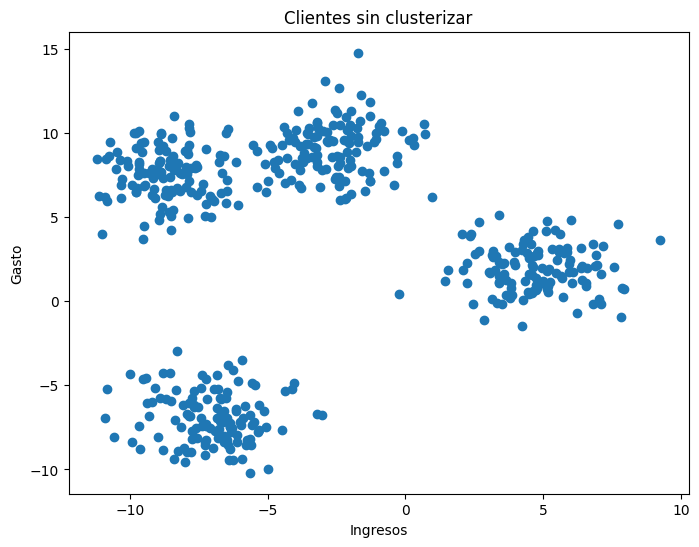

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['Ingresos'],
    data['Gasto']
)

plt.title('Clientes sin clusterizar')
plt.xlabel('Ingresos')
plt.ylabel('Gasto')

plt.show()

## Escalado de variables

In [5]:
# IMPORTANTE:
# K-Means es sensible a escalas

scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

## K means

In [16]:
modelo = KMeans(n_clusters = 3, random_state=42 )

In [17]:
modelo.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

## Predicción

In [18]:
clusters = modelo.predict(X_scaled)

In [19]:
clusters

array([1, 2, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 0, 0, 1, 1, 2, 0, 1, 1,
       1, 0, 0, 0, 2, 1, 2, 1, 1, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0, 2,
       2, 1, 0, 2, 0, 2, 2, 1, 1, 1, 1, 2, 0, 1, 2, 0, 2, 1, 1, 1, 1, 1,
       0, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 2, 0, 1, 2, 2, 1, 0, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 2, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0, 0,
       1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1,
       1, 2, 1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 2, 2, 0, 2, 0, 1, 2, 1, 2, 1, 2, 0, 0, 0, 2,
       1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 1,
       2, 2, 0, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 0, 0, 1, 2, 1,
       0, 1, 0, 2, 2, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2,

In [20]:
# Agregamos clusters al DataFrame
data['Cluster'] = clusters


In [12]:
data.head()

,Ingresos,Gasto,Cluster
0,-7.114418,6.268758,1
1,-10.924957,-6.961552,2
2,7.924583,0.760722,0
3,-3.097360,6.819014,3
4,-5.077806,-7.492223,2


In [13]:
centroides = modelo.cluster_centers_

print("Centroides escalados:")
print(centroides)

Centroides escalados:
[[ 1.51361513 -0.15657684]
 [-0.97604041  0.72037701]
 [-0.68228657 -1.52370499]
 [ 0.13581699  0.9580038 ]]


## Visualizacion grupos

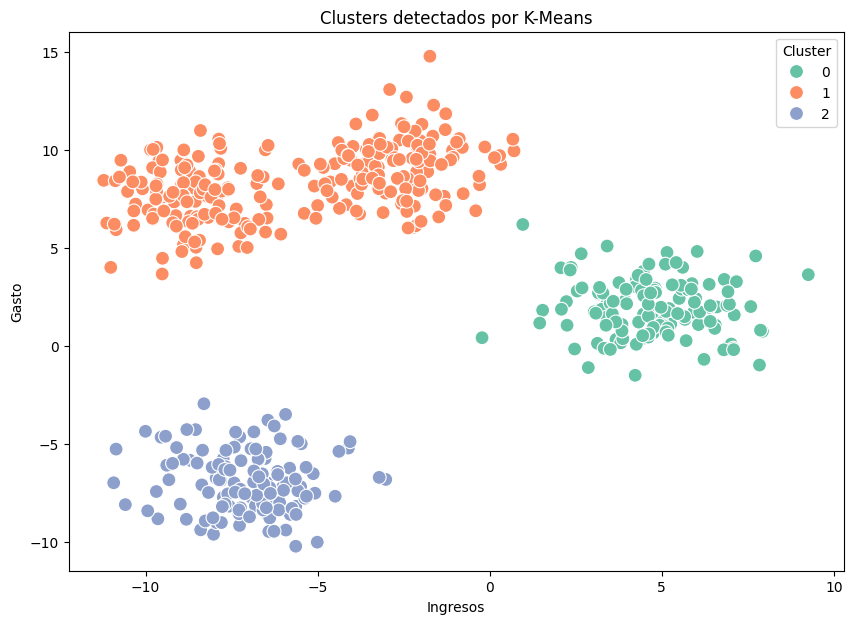

In [21]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=data['Ingresos'],
    y=data['Gasto'],
    hue=data['Cluster'],
    palette='Set2',
    s=100
)

plt.title('Clusters detectados por K-Means')

plt.show()

Cada color representa un cluster distinto.

Posibles segmentos encontrados:

Cluster 0:
Clientes con ingresos altos y gasto alto.

Cluster 1:
Clientes de bajo gasto.

Cluster 2:
Clientes intermedios.

Cluster 3:
Clientes premium.

El objetivo de clustering es descubrir
grupos similares automáticamente.

## Metricas

In [22]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')

Silhouette Score: 0.6956


**Silhouette Score**:
- Cercano a 1 -> buen clustering
- Cercano a 0 -> clusters mezclados
- Negativo -> mala separación

## Ejemplo Mall

El dataset Mall Customers representa información de clientes de un centro comercial ficticio.

La idea principal es descubrir grupos de clientes con comportamientos similares.

In [23]:
data = pd.read_csv('Mall_Customers.csv')

In [24]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [25]:
print("\nShape:")
print(data.shape)

print("\nInformación:")
print(data.info())

print("\nNulos:")
print(data.isnull().sum())


Shape:
(200, 5)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Nulos:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Modelado

Vamos a clusterizar utilizando:
- Annual Income (k$)
- Spending Score (1-100)

In [26]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

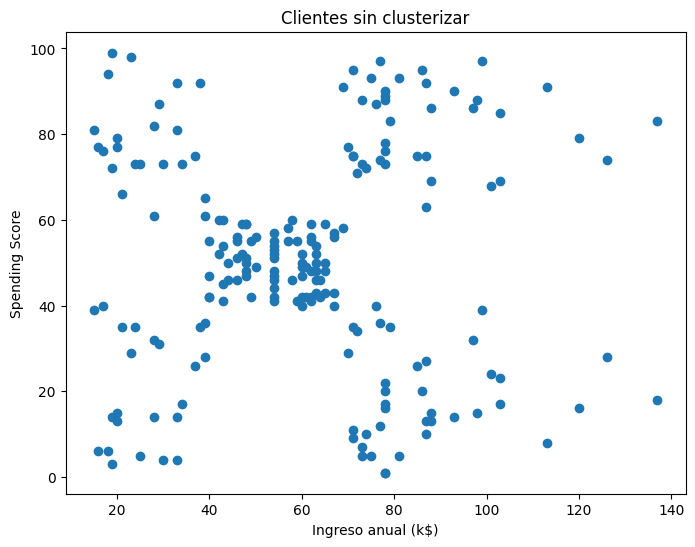

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.title('Clientes sin clusterizar')

plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')

plt.show()

## Escalado

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Método del codo

In [29]:
inertia = []

k_values = range(1, 11)

for k in k_values:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertia.append(modelo.inertia_)


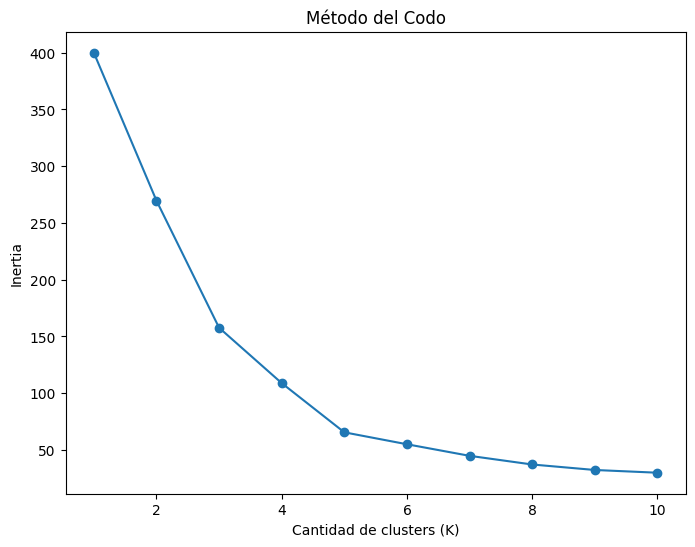

In [30]:
plt.figure(figsize=(8,6))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title('Método del Codo')

plt.xlabel('Cantidad de clusters (K)')
plt.ylabel('Inertia')

plt.show()

## Elección del modelo

In [39]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [40]:
clusters = kmeans.predict(X_scaled)

# Agregamos clusters al DataFrame

data['Cluster'] = clusters

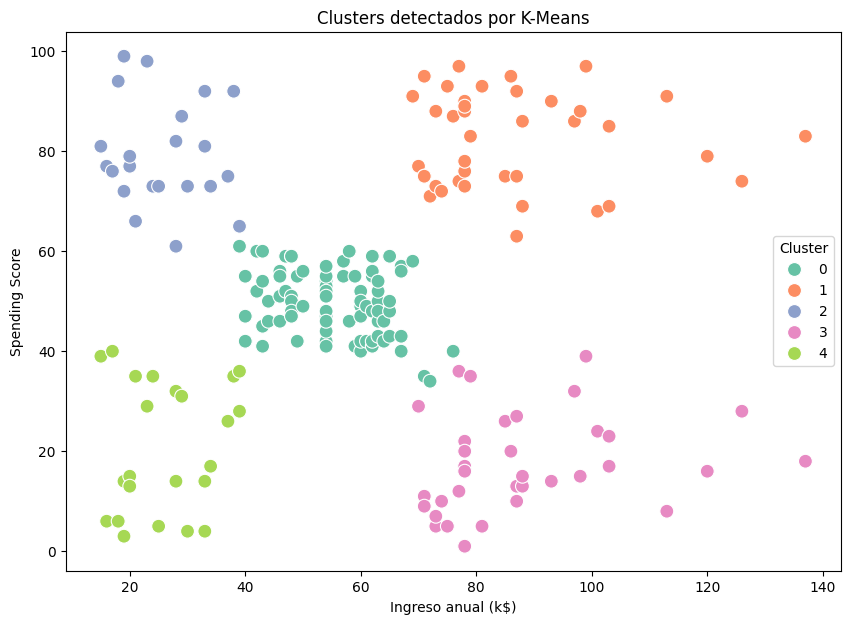

In [41]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=data['Annual Income (k$)'],
    y=data['Spending Score (1-100)'],
    hue=data['Cluster'],
    palette='Set2',
    s=100
)

plt.title('Clusters detectados por K-Means')

plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')

plt.show()

## Métrica

In [42]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')


Silhouette Score: 0.5547


## Análisis de grupos

In [43]:
resumen = data.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("\nPromedios por cluster:")
print(resumen)


Promedios por cluster:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
